<a href="https://colab.research.google.com/github/AngelTroncoso/Alergias/blob/main/01_02_An%C3%A1lisis_de_Estructuras_PDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nuevo Punto de Partida para Análisis de Estructuras PDB

Este cuaderno ha sido limpiado para proporcionar un punto de partida funcional para la descarga y análisis de estructuras PDB. Nos centraremos en dos librerías principales:

*   **`requests`**: Para descargar archivos PDB directamente desde la base de datos RCSB PDB.
*   **`Biopython`**: Para parsear y analizar el contenido de los archivos PDB descargados.

**Nota sobre `rcsbsearchapi`**: La librería `rcsbsearchapi` ha presentado problemas de compatibilidad y errores (`AttributeError`, `ImportError`) con las versiones disponibles, lo que impide su uso fiable para consultas avanzadas. Si necesitas realizar búsquedas complejas en la base de datos, se podría explorar la construcción manual de consultas a la API de RCSB PDB usando `requests` o buscar alternativas en el futuro.

### 1. Descargar archivos PDB usando `requests`

Esta función te permite descargar cualquier archivo PDB conociendo su ID. La URL base para la descarga es `https://files.rcsb.org/download/{pdb_id}.pdb`.

In [ ]:
import requests

def download_pdb_file(pdb_id, output_dir='./'):
    """
    Descarga un archivo PDB desde RCSB PDB.

    Args:
        pdb_id (str): El ID de 4 caracteres de la estructura PDB.
        output_dir (str): Directorio donde guardar el archivo descargado.
    """
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    filename = f"{output_dir}{pdb_id}.pdb"

    print(f"Descargando {pdb_id} de {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status() # Lanza una excepción si la solicitud no fue exitosa

    with open(filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Archivo {filename} descargado exitosamente.")

# Ejemplo de uso: Descargamos el archivo 5DM2.pdb
pdb_id_to_download = "5DM2"
download_pdb_file(pdb_id_to_download)

Descargando 5DM2 de https://files.rcsb.org/download/5DM2.pdb...
Archivo ./5DM2.pdb descargado exitosamente.


### 2. Leer y Analizar Archivos PDB con Biopython

Una vez descargado el archivo, Biopython es la herramienta ideal para cargar la estructura y acceder a sus componentes como modelos, cadenas, residuos y átomos.

In [ ]:
# Instalar Biopython si no está instalado
!pip install biopython

In [ ]:
from Bio.PDB import PDBParser

# Crear un objeto PDBParser
parser = PDBParser()

# Ruta al archivo PDB descargado
pdb_file_path = './5DM2.pdb'

# Parsear la estructura
structure = parser.get_structure('5DM2', pdb_file_path)

print(f"ID de la estructura: {structure.get_id()}")
print(f"Número de modelos: {len(structure)}")

for model in structure:
    print(f"  Modelo ID: {model.get_id()}")
    print(f"  Número de cadenas en el modelo {model.get_id()}: {len(model)}")
    for chain in model:
        print(f"    Cadena ID: {chain.get_id()}")
        print(f"    Número de residuos en la cadena {chain.get_id()}: {len(chain)}")
        # Mostrar los primeros 5 residuos como ejemplo para evitar una salida muy larga
        for i, residue in enumerate(chain):
            if i < 5:
                print(f"      Residuo: {residue.get_resname()}, ID: {residue.get_id()[1]}")
            else:
                break
        if len(chain) > 5:
            print("      ...")


ID de la estructura: 5DM2
Número de modelos: 1
  Modelo ID: 0
  Número de cadenas en el modelo 0: 1
    Cadena ID: A
    Número de residuos en la cadena A: 497
      Residuo: ILE, ID: 2
      Residuo: GLN, ID: 3
      Residuo: GLU, ID: 4
      Residuo: LYS, ID: 5
      Residuo: ILE, ID: 6
      ...


### 3. Extraer y Listar Átomos de una Cadena Específica

Una vez que tienes la estructura cargada, puedes navegar a través de sus componentes (modelos, cadenas, residuos) para acceder a los átomos. Este ejemplo muestra cómo listar todos los átomos de una cadena específica (por ejemplo, la cadena 'A').

In [ ]:
from Bio.PDB import PDBParser

# Asegúrate de que el archivo PDB haya sido descargado y Biopython instalado
# (Esto se asume que ya lo ejecutaste en las celdas anteriores)

# Crear un objeto PDBParser
parser = PDBParser()

# Ruta al archivo PDB descargado
pdb_file_path = './5DM2.pdb'

# Parsear la estructura (si no está ya cargada)
structure = parser.get_structure('5DM2', pdb_file_path)

# Especifica el ID del modelo y de la cadena que te interesa
# En este ejemplo, el modelo 0 y la cadena 'A' son los que existen en 5DM2
model_id_to_explore = 0
chain_id_to_explore = 'A'

print(f"Listando átomos de la Cadena '{chain_id_to_explore}' en el Modelo {model_id_to_explore}...")

atom_count = 0
for model in structure:
    if model.get_id() == model_id_to_explore:
        for chain in model:
            if chain.get_id() == chain_id_to_explore:
                print(f"  Cadena encontrada: {chain.get_id()}")
                for residue in chain:
                    # Imprimir información del residuo para contexto
                    # print(f"    Residuo: {residue.get_resname()} (ID: {residue.get_id()[1]}) -")
                    for atom in residue:
                        print(f"      Átomo: {atom.get_id()}, Elemento: {atom.element}, Coordenadas: {atom.get_coord()}")
                        atom_count += 1
                break # Salir del bucle de cadenas una vez encontrada
        break # Salir del bucle de modelos una vez encontrado

print(f"\nTotal de átomos listados en la Cadena '{chain_id_to_explore}': {atom_count}")


Listando átomos de la Cadena 'A' en el Modelo 0...
  Cadena encontrada: A
      Átomo: N, Elemento: N, Coordenadas: [5.8371e+01 1.2000e-02 2.3479e+01]
      Átomo: CA, Elemento: C, Coordenadas: [57.582 -1.151 22.974]
      Átomo: C, Elemento: C, Coordenadas: [58.212 -2.477 23.401]
      Átomo: O, Elemento: O, Coordenadas: [57.502 -3.448 23.648]
      Átomo: CB, Elemento: C, Coordenadas: [57.366 -1.093 21.436]
      Átomo: CG1, Elemento: C, Coordenadas: [56.365 -2.164 20.969]
      Átomo: CG2, Elemento: C, Coordenadas: [58.686 -1.227 20.682]
      Átomo: CD1, Elemento: C, Coordenadas: [55.001 -2.104 21.629]
      Átomo: N, Elemento: N, Coordenadas: [59.539 -2.502 23.505]
      Átomo: CA, Elemento: C, Coordenadas: [60.265 -3.707 23.908]
      Átomo: C, Elemento: C, Coordenadas: [59.847 -4.176 25.305]
      Átomo: O, Elemento: O, Coordenadas: [59.727 -5.379 25.553]
      Átomo: CB, Elemento: C, Coordenadas: [61.776 -3.476 23.849]
      Átomo: CG, Elemento: C, Coordenadas: [62.282 -3.048 2

### 4. Plantilla para calcular la distancia euclidiana entre dos átomos

Modifica los valores de `residue_id_1`, `atom_name_1`, `residue_id_2` y `atom_name_2` en la siguiente celda para calcular la distancia entre diferentes átomos.

In [ ]:
from Bio.PDB import PDBParser
import numpy as np # Importamos numpy para el cálculo de la norma

# --- PARÁMETROS CONFIGURABLES ---
# Modifica estos valores para especificar los átomos que quieres analizar
model_to_use = 0    # ID del modelo (generalmente 0 si solo hay uno)
chain_to_use = 'A'  # ID de la cadena (ej: 'A', 'B', etc.)

# Primer átomo
residue_id_1 = 2    # ID numérico del residuo
atom_name_1 = 'CA'  # Nombre del átomo (ej: 'N', 'CA', 'C', 'O', 'CB', etc.)

# Segundo átomo
residue_id_2 = 6    # ID numérico del residuo
atom_name_2 = 'CA'  # Nombre del átomo
# ---------------------------------

# Asegurarse de que la estructura PDB esté cargada.
# Si 'structure' no está disponible en este momento, descomenta y ejecuta lo siguiente:
# parser = PDBParser()
# pdb_file_path = './5DM2.pdb' # Asegúrate de que esta ruta sea correcta
# structure = parser.get_structure('5DM2', pdb_file_path)

atom1_obj = None
atom2_obj = None

# Buscar los átomos específicos en la estructura
for model in structure:
    if model.get_id() == model_to_use:
        for chain in model:
            if chain.get_id() == chain_to_use:
                for residue in chain:
                    res_id_tuple = residue.get_id()
                    # Biopython almacena el ID del residuo en el segundo elemento de la tupla (residuo_numero)
                    if res_id_tuple[1] == residue_id_1:
                        if atom_name_1 in residue:
                            atom1_obj = residue[atom_name_1]
                    if res_id_tuple[1] == residue_id_2:
                        if atom_name_2 in residue:
                            atom2_obj = residue[atom_name_2]
                break # Salir del bucle de cadenas una vez encontrada
        break # Salir del bucle de modelos una vez encontrado

if atom1_obj is not None and atom2_obj is not None:
    # Obtener los vectores de posición como arrays de NumPy
    vec1 = atom1_obj.get_vector().get_array()
    vec2 = atom2_obj.get_vector().get_array()

    # Calcular la distancia euclidiana usando numpy.linalg.norm
    distance = np.linalg.norm(vec1 - vec2)
    print(f"La distancia euclidiana entre el átomo {atom_name_1} (Residuo {residue_id_1}) y el átomo {atom_name_2} (Residuo {residue_id_2}) en la cadena {chain_to_use} es: {distance:.3f} Å")
else:
    print(f"Advertencia: No se pudieron encontrar ambos átomos en la cadena {chain_to_use} del modelo {model_to_use}.")
    if atom1_obj is None:
        print(f"  - El átomo {atom_name_1} del residuo {residue_id_1} no fue encontrado.")
    if atom2_obj is None:
        print(f"  - El átomo {atom_name_2} del residuo {residue_id_2} no fue encontrado.")

La distancia euclidiana entre el átomo CA (Residuo 2) y el átomo CA (Residuo 6) en la cadena A es: 6.178 Å


preparan

### 5. Task
Analyze structural data of relevant dust mite allergens by identifying their PDB IDs, downloading the corresponding PDB files, performing basic structural analysis (models, chains, residues, atoms), identifying surface-exposed residues and potential epitopic regions, and calculating Euclidean distances between key residues within these epitopic regions to inform the development of allergy solutions such as inhibitors or epitope-based vaccines.

## Identificar Alérgenos Relevantes y Sus PDB IDs

### Subtask:
Identificar alérgenos de ácaros del polvo o componentes del polvo relevantes y obtener sus IDs de PDB para el análisis estructural.

#### Instructions
1.  **Identificar Alérgenos Específicos:** La siguiente celda de código ya contiene una lista de PDB IDs para los alérgenos específicos solicitados: Der p 1, Der f 1, Der p 2, Der p 7 y Der p 23.
2.  **Verificar/Modificar la Lista de PDB IDs:** Revisa la lista `allergen_pdb_ids` en la celda de código. Si necesitas añadir o modificar algún ID, hazlo directamente en esa lista. Por ejemplo: `allergen_pdb_ids = ['1GP2', '1DF1', '1POA', '1K6U', '5DM2']`.

**Reasoning**:
The previous markdown block outlined the instructions for creating a Python list of PDB IDs. This code block provides an initial placeholder list for the user to populate with the PDB IDs they identified manually.



In [ ]:
# Esta lista contendrá los IDs de PDB de los alérgenos que identificaste manualmente.
# Los siguientes IDs son para Der p 1, Der f 1, Der p 2, Der p 7 y Der p 23, respectivamente.
allergen_pdb_ids = ['1GP2', '1DF1', '1POA', '1K6U', '5DM2']

print(f"Lista de IDs de PDB para alérgenos: {allergen_pdb_ids}")

Lista de IDs de PDB para alérgenos: ['1GP2', '1DF1', '1POA', '1K6U', '5DM2']


## Descargar Múltiples Archivos PDB de Alérgenos

### Subtask:
Descargar todos los archivos PDB correspondientes a los IDs de alérgenos identificados en la lista `allergen_pdb_ids`.


**Reasoning**:
The user wants to download multiple PDB files based on the `allergen_pdb_ids` list. I will iterate through this list and call the previously defined `download_pdb_file` function for each ID.



In [ ]:
for pdb_id in allergen_pdb_ids:
    download_pdb_file(pdb_id)
print("Todos los archivos PDB de alérgenos han sido descargados.")

Descargando 1GP2 de https://files.rcsb.org/download/1GP2.pdb...
Archivo ./1GP2.pdb descargado exitosamente.
Descargando 1DF1 de https://files.rcsb.org/download/1DF1.pdb...
Archivo ./1DF1.pdb descargado exitosamente.
Descargando 1POA de https://files.rcsb.org/download/1POA.pdb...
Archivo ./1POA.pdb descargado exitosamente.
Descargando 1K6U de https://files.rcsb.org/download/1K6U.pdb...
Archivo ./1K6U.pdb descargado exitosamente.
Descargando 5DM2 de https://files.rcsb.org/download/5DM2.pdb...
Archivo ./5DM2.pdb descargado exitosamente.
Todos los archivos PDB de alérgenos han sido descargados.


## Análisis Estructural Básico de Alérgenos

### Subtask:
Parsear las estructuras PDB descargadas, extrayendo información sobre modelos, cadenas, residuos y átomos para entender la composición general de cada alérgeno.


**Reasoning**:
The user wants to parse each downloaded PDB file and extract basic structural information such as models, chains, residues, and atoms. I will write a Python code block to iterate through the `allergen_pdb_ids` list, parse each PDB file, and print the requested details.



In [ ]:
from Bio.PDB import PDBParser

# Crear un objeto PDBParser si no existe
# Aseguramos que 'parser' esté definido incluso si las celdas anteriores no se ejecutaron en orden.
# Aunque ya se importó y creó en celdas anteriores, es buena práctica asegurarse para esta tarea específica.
parser = PDBParser()

print("Iniciando análisis estructural básico para los alérgenos...\n")

for pdb_id in allergen_pdb_ids:
    pdb_file_path = f'./{pdb_id}.pdb'
    try:
        structure = parser.get_structure(pdb_id, pdb_file_path)

        print(f"=== Análisis para la estructura PDB: {structure.get_id()} ===")
        print(f"ID de la estructura: {structure.get_id()}")
        print(f"Número de modelos: {len(structure)}")

        for model in structure:
            print(f"  Modelo ID: {model.get_id()}")
            print(f"  Número de cadenas en el modelo {model.get_id()}: {len(model)}")
            for chain in model:
                print(f"    Cadena ID: {chain.get_id()}")
                print(f"    Número de residuos en la cadena {chain.get_id()}: {len(chain)}")
                print("      Primeros 5 residuos (Residuo: Nombre, ID):")
                # Mostrar los primeros 5 residuos como ejemplo para evitar una salida muy larga
                for i, residue in enumerate(chain):
                    if i < 5:
                        # get_resname() para el nombre, get_id()[1] para el número de secuencia
                        print(f"        Residuo: {residue.get_resname()}, ID: {residue.get_id()[1]}")
                    else:
                        break
                if len(chain) > 5:
                    print("        ...")
        print("\n")

    except Exception as e:
        print(f"Error al procesar el archivo {pdb_file_path}: {e}\n")

print("Análisis estructural básico completado para todos los alérgenos.\n")

Iniciando análisis estructural básico para los alérgenos...

=== Análisis para la estructura PDB: 1GP2 ===
ID de la estructura: 1GP2
Número de modelos: 1
  Modelo ID: 0
  Número de cadenas en el modelo 0: 3
    Cadena ID: A
    Número de residuos en la cadena A: 570
      Primeros 5 residuos (Residuo: Nombre, ID):
        Residuo: LEU, ID: 5
        Residuo: SER, ID: 6
        Residuo: ALA, ID: 7
        Residuo: GLU, ID: 8
        Residuo: ASP, ID: 9
        ...
    Cadena ID: B
    Número de residuos en la cadena B: 481
      Primeros 5 residuos (Residuo: Nombre, ID):
        Residuo: SER, ID: 2
        Residuo: GLU, ID: 3
        Residuo: LEU, ID: 4
        Residuo: ASP, ID: 5
        Residuo: GLN, ID: 6
        ...
    Cadena ID: G
    Número de residuos en la cadena G: 77
      Primeros 5 residuos (Residuo: Nombre, ID):
        Residuo: SER, ID: 8
        Residuo: ILE, ID: 9
        Residuo: ALA, ID: 10
        Residuo: GLN, ID: 11
        Residuo: ALA, ID: 12
        ...


=== An

## Analisis comparativos de los modelos analizados

In [ ]:
from Bio.PDB import PDBParser

# Aseguramos que 'parser' esté definido
parser = PDBParser()

print("\n--- Análisis Comparativo de Estructuras PDB de Alérgenos ---")
print("-----------------------------------------------------------\n")

# Diccionario para almacenar los datos comparativos
comparative_data = {}

for pdb_id in allergen_pdb_ids:
    pdb_file_path = f'./{pdb_id}.pdb'
    try:
        structure = parser.get_structure(pdb_id, pdb_file_path)

        num_models = len(structure)
        models_data = []

        total_residues_in_structure = 0

        for model in structure:
            model_id = model.get_id()
            num_chains = len(model)
            chains_data = []

            for chain in model:
                chain_id = chain.get_id()
                num_residues = len(chain)
                total_residues_in_structure += num_residues
                chains_data.append({'chain_id': chain_id, 'num_residues': num_residues})

            models_data.append({'model_id': model_id, 'num_chains': num_chains, 'chains': chains_data})

        comparative_data[pdb_id] = {
            'num_models': num_models,
            'total_residues': total_residues_in_structure,
            'models': models_data
        }

    except Exception as e:
        comparative_data[pdb_id] = {'error': f"Error al procesar: {e}"}

# Imprimir el análisis comparativo
for pdb_id, data in comparative_data.items():
    print(f"--- PDB ID: {pdb_id} ---")
    if 'error' in data:
        print(f"  Error: {data['error']}")
    else:
        print(f"  Número total de modelos: {data['num_models']}")
        print(f"  Número total de residuos en la estructura: {data['total_residues']}")
        for model_info in data['models']:
            print(f"    Modelo ID: {model_info['model_id']}, Número de cadenas: {model_info['num_chains']}")
            for chain_info in model_info['chains']:
                print(f"      Cadena ID: {chain_info['chain_id']}, Residuos: {chain_info['num_residues']}")
    print("\n")

print("--- Análisis Comparativo Completado ---")


--- Análisis Comparativo de Estructuras PDB de Alérgenos ---
-----------------------------------------------------------

--- PDB ID: 1GP2 ---
  Número total de modelos: 1
  Número total de residuos en la estructura: 1128
    Modelo ID: 0, Número de cadenas: 3
      Cadena ID: A, Residuos: 570
      Cadena ID: B, Residuos: 481
      Cadena ID: G, Residuos: 77


--- PDB ID: 1DF1 ---
  Número total de modelos: 1
  Número total de residuos en la estructura: 1066
    Modelo ID: 0, Número de cadenas: 2
      Cadena ID: A, Residuos: 531
      Cadena ID: B, Residuos: 535


--- PDB ID: 1POA ---
  Número total de modelos: 1
  Número total de residuos en la estructura: 271
    Modelo ID: 0, Número de cadenas: 1
      Cadena ID: A, Residuos: 271


--- PDB ID: 1K6U ---
  Número total de modelos: 1
  Número total de residuos en la estructura: 210
    Modelo ID: 0, Número de cadenas: 1
      Cadena ID: A, Residuos: 210


--- PDB ID: 5DM2 ---
  Número total de modelos: 1
  Número total de residuos e

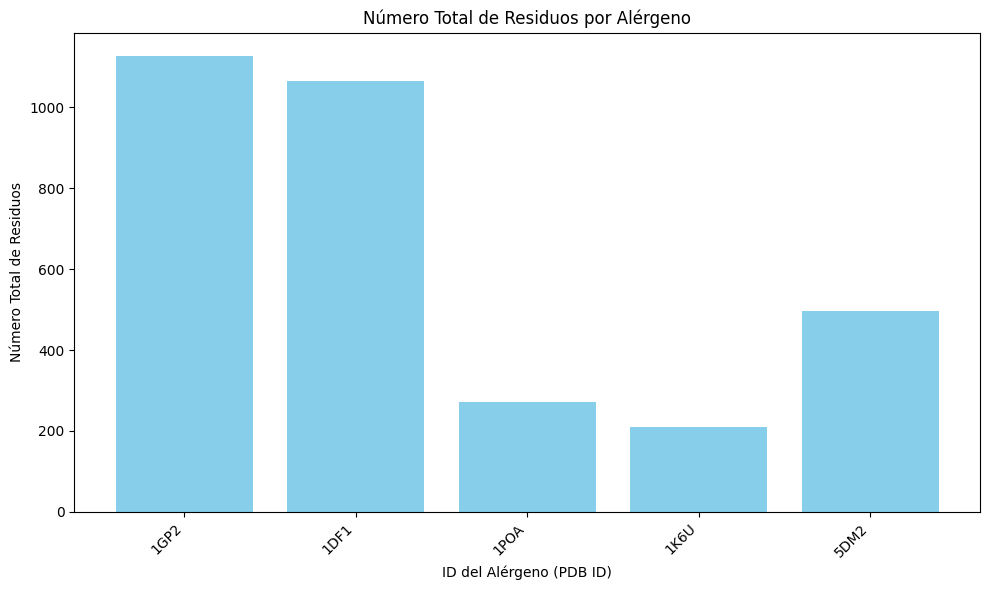

In [ ]:
import matplotlib.pyplot as plt

# Preparar los datos para la graficación
pdb_ids = []
total_residues = []

for pdb_id, data in comparative_data.items():
    if 'error' not in data:
        pdb_ids.append(pdb_id)
        total_residues.append(data['total_residues'])

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(pdb_ids, total_residues, color='skyblue')
plt.xlabel('ID del Alérgeno (PDB ID)')
plt.ylabel('Número Total de Residuos')
plt.title('Número Total de Residuos por Alérgeno')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

## 6. Identificación de Aminoácidos Más Frecuentes por Alérgeno

Este script analizará cada estructura PDB descargada para contar la ocurrencia de cada tipo de aminoácido. Luego, mostrará los aminoácidos más frecuentes para cada alérgeno. Esto puede dar una idea de la composición general y las posibles características estructurales de cada proteína.

In [ ]:
from Bio.PDB import PDBParser
from collections import Counter

# Crear un objeto PDBParser
parser = PDBParser()

print("\n--- Análisis de Frecuencia de Aminoácidos por Alérgeno ---")
print("-----------------------------------------------------------\n")

# Diccionario para almacenar los resultados
allergen_amino_acid_counts = {}

for pdb_id in allergen_pdb_ids:
    pdb_file_path = f'./{pdb_id}.pdb'
    try:
        structure = parser.get_structure(pdb_id, pdb_file_path)
        amino_acid_counter = Counter()

        for model in structure:
            for chain in model:
                for residue in chain:
                    # Ignorar residuos no-estándar (e.g., heteroátomos como agua, ligandos)
                    if residue.get_resname() in ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL']:
                        amino_acid_counter[residue.get_resname()] += 1

        allergen_amino_acid_counts[pdb_id] = amino_acid_counter

        print(f"=== Frecuencia de Aminoácidos para {pdb_id} ===")
        if amino_acid_counter:
            # Mostrar los 10 aminoácidos más frecuentes
            print("  Top 10 Aminoácidos más frecuentes:")
            for aa, count in amino_acid_counter.most_common(10):
                print(f"    - {aa}: {count}")
        else:
            print("  No se encontraron aminoácidos estándar en esta estructura.")
        print("\n")

    except Exception as e:
        print(f"Error al procesar el archivo {pdb_file_path}: {e}\n")

print("--- Análisis de Frecuencia de Aminoácidos Completado ---")


--- Análisis de Frecuencia de Aminoácidos por Alérgeno ---
-----------------------------------------------------------

=== Frecuencia de Aminoácidos para 1GP2 ===
  Top 10 Aminoácidos más frecuentes:
    - ALA: 72
    - LEU: 61
    - ASP: 58
    - THR: 49
    - SER: 48
    - ILE: 47
    - LYS: 44
    - GLY: 43
    - GLU: 42
    - ARG: 42


=== Frecuencia de Aminoácidos para 1DF1 ===
  Top 10 Aminoácidos más frecuentes:
    - LEU: 76
    - GLU: 60
    - THR: 54
    - ILE: 52
    - GLY: 52
    - ALA: 52
    - ARG: 46
    - PRO: 46
    - GLN: 42
    - VAL: 42


=== Frecuencia de Aminoácidos para 1POA ===
  Top 10 Aminoácidos más frecuentes:
    - CYS: 14
    - ALA: 11
    - ASN: 10
    - ASP: 10
    - GLY: 10
    - TYR: 9
    - SER: 6
    - LEU: 5
    - LYS: 5
    - THR: 5


=== Frecuencia de Aminoácidos para 1K6U ===
  Top 10 Aminoácidos más frecuentes:
    - ALA: 8
    - ARG: 7
    - CYS: 6
    - GLY: 6
    - PHE: 4
    - TYR: 4
    - PRO: 3
    - LEU: 3
    - ASN: 3
    - LYS: 3


==


--- Gráficos de Frecuencia de Aminoácidos por Alérgeno ---
-----------------------------------------------------------



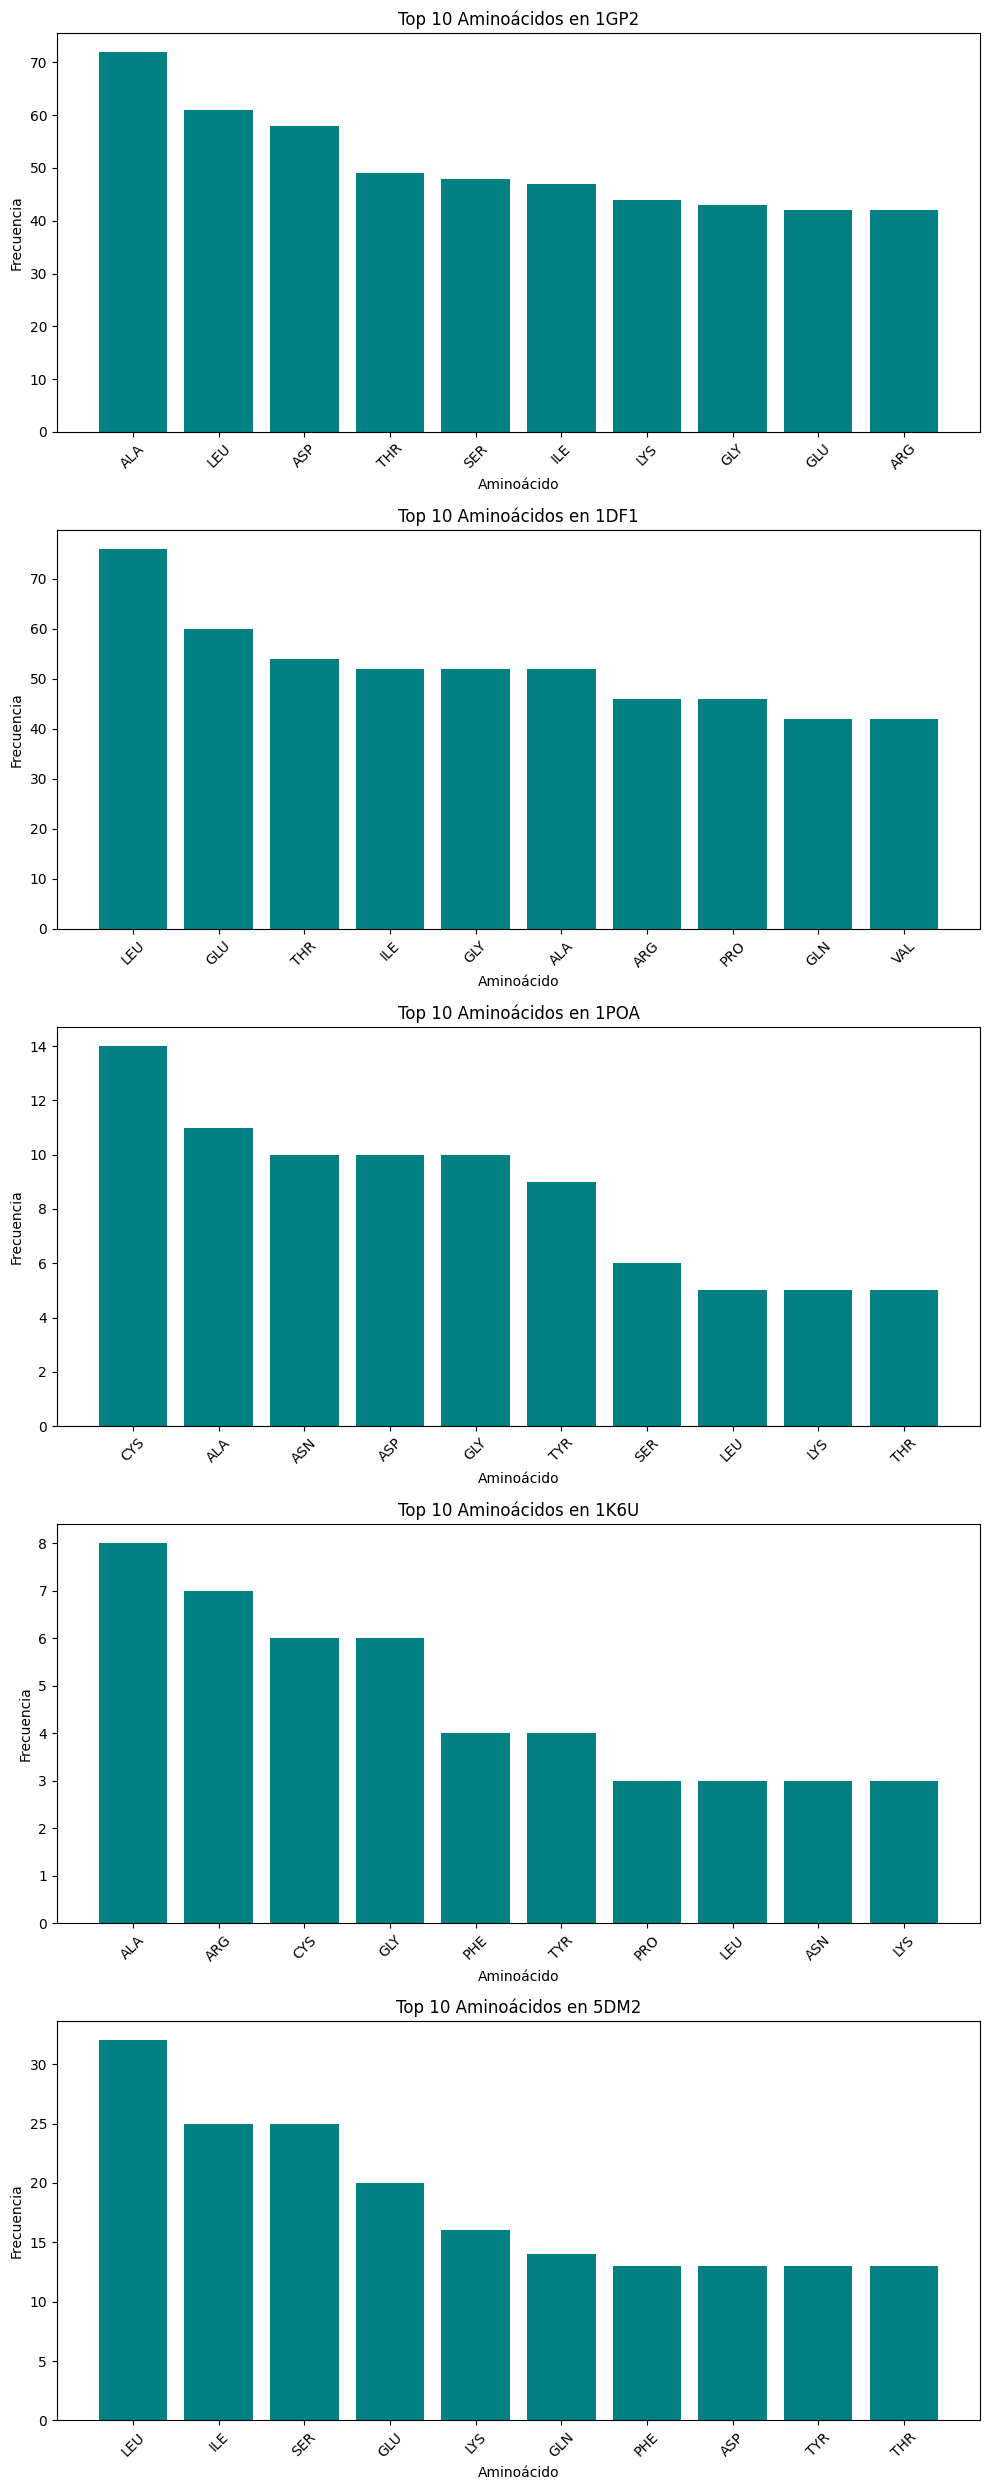


--- Gráficos de Frecuencia de Aminoácidos Completados ---


In [ ]:
import matplotlib.pyplot as plt

print("\n--- Gráficos de Frecuencia de Aminoácidos por Alérgeno ---")
print("-----------------------------------------------------------\n")

num_allergens = len(allergen_amino_acid_counts)

# Create a figure with subplots for each allergen
# Adjust figsize based on the number of allergens to ensure readability
fig, axes = plt.subplots(num_allergens, 1, figsize=(10, num_allergens * 5), sharex=False)

# Ensure axes is an array even if there's only one subplot
if num_allergens == 1:
    axes = [axes]

for i, (pdb_id, counts) in enumerate(allergen_amino_acid_counts.items()):
    if counts:
        # Get the top 10 most common amino acids
        top_aa = counts.most_common(10)
        aa_names = [item[0] for item in top_aa]
        aa_values = [item[1] for item in top_aa]

        axes[i].bar(aa_names, aa_values, color='teal')
        axes[i].set_title(f'Top 10 Aminoácidos en {pdb_id}')
        axes[i].set_xlabel('Aminoácido')
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].set_title(f'No se encontraron aminoácidos estándar para {pdb_id}')
        axes[i].text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

print("\n--- Gráficos de Frecuencia de Aminoácidos Completados ---")

### 7. Calcular el porcentaje de aminoácidos hidrofóbicos por alérgeno

Este script calcula el porcentaje de aminoácidos hidrofóbicos para cada alérgeno. Los aminoácidos hidrofóbicos suelen ser importantes para la estructura de las proteínas y sus interacciones.

In [ ]:
from Bio.PDB import PDBParser
from collections import Counter

# Lista de aminoácidos hidrofóbicos comunes
hydrophobic_amino_acids = ['ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PHE', 'TRP', 'PRO', 'TYR']

print("\n--- Cálculo del Porcentaje de Aminoácidos Hidrofóbicos por Alérgeno ---")
print("----------------------------------------------------------------------\n")

# Aseguramos que 'allergen_amino_acid_counts' esté disponible del paso anterior
# Si no lo estuviera, se podría ejecutar de nuevo el bloque de análisis de frecuencia de AA

for pdb_id, counts in allergen_amino_acid_counts.items():
    total_amino_acids = sum(counts.values())
    hydrophobic_count = 0

    for aa_name, count in counts.items():
        if aa_name in hydrophobic_amino_acids:
            hydrophobic_count += count

    if total_amino_acids > 0:
        percentage_hydrophobic = (hydrophobic_count / total_amino_acids) * 100
        print(f"Alérgeno {pdb_id}: {percentage_hydrophobic:.2f}% de aminoácidos hidrofóbicos ({hydrophobic_count}/{total_amino_acids})")
    else:
        print(f"Alérgeno {pdb_id}: No se encontraron aminoácidos estándar para calcular el porcentaje hidrofóbico.")

print("\n--- Cálculo Completado ---")


--- Cálculo del Porcentaje de Aminoácidos Hidrofóbicos por Alérgeno ---
----------------------------------------------------------------------

Alérgeno 1GP2: 42.33% de aminoácidos hidrofóbicos (312/737)
Alérgeno 1DF1: 46.43% de aminoácidos hidrofóbicos (390/840)
Alérgeno 1POA: 38.14% de aminoácidos hidrofóbicos (45/118)
Alérgeno 1K6U: 43.10% de aminoácidos hidrofóbicos (25/58)
Alérgeno 5DM2: 45.35% de aminoácidos hidrofóbicos (117/258)

--- Cálculo Completado ---


### 8. Graficar el porcentaje de aminoácidos hidrofóbicos por alérgeno

Este gráfico visualiza el porcentaje de aminoácidos hidrofóbicos para cada uno de los alérgenos analizados, facilitando la comparación directa de esta característica entre ellos.


--- Generando Gráfico Comparativo de Porcentaje de Aminoácidos Hidrofóbicos ---


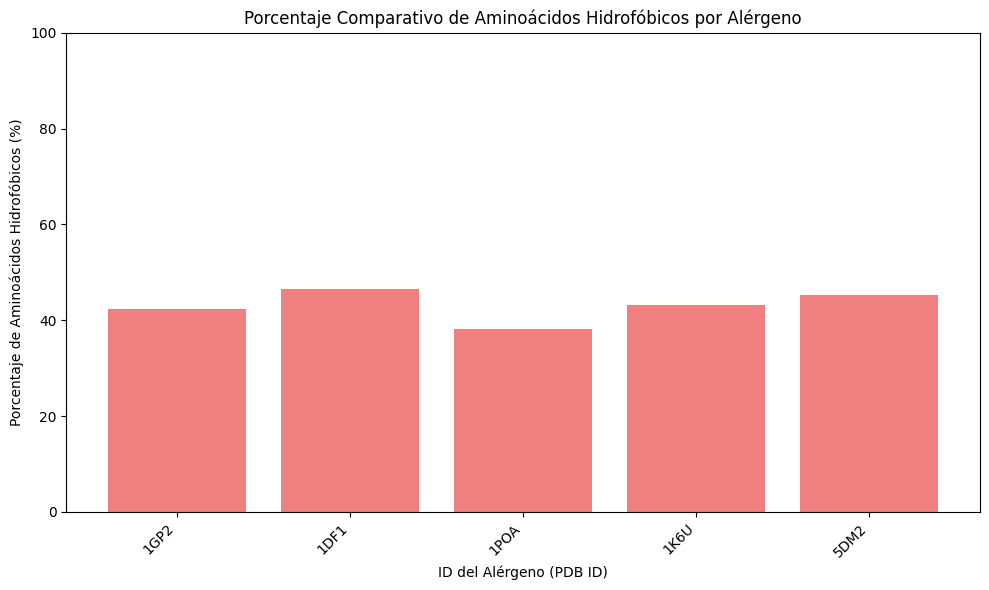


--- Gráfico de Porcentaje de Aminoácidos Hidrofóbicos Completado ---


In [ ]:
import matplotlib.pyplot as plt

print("\n--- Generando Gráfico Comparativo de Porcentaje de Aminoácidos Hidrofóbicos ---")

pdb_ids_for_plot = []
percentage_hydrophobic_for_plot = []

for pdb_id, counts in allergen_amino_acid_counts.items():
    total_amino_acids = sum(counts.values())
    hydrophobic_count = 0

    for aa_name, count in counts.items():
        if aa_name in hydrophobic_amino_acids:
            hydrophobic_count += count

    if total_amino_acids > 0:
        percentage_hydrophobic = (hydrophobic_count / total_amino_acids) * 100
        pdb_ids_for_plot.append(pdb_id)
        percentage_hydrophobic_for_plot.append(percentage_hydrophobic)
    else:
        print(f"Advertencia: No se encontraron aminoácidos estándar para {pdb_id}. No incluido en el gráfico.")

if pdb_ids_for_plot:
    plt.figure(figsize=(10, 6))
    plt.bar(pdb_ids_for_plot, percentage_hydrophobic_for_plot, color='lightcoral')
    plt.xlabel('ID del Alérgeno (PDB ID)')
    plt.ylabel('Porcentaje de Aminoácidos Hidrofóbicos (%)')
    plt.title('Porcentaje Comparativo de Aminoácidos Hidrofóbicos por Alérgeno')
    plt.ylim(0, 100) # Asegurar que el eje Y vaya de 0 a 100
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos suficientes para generar el gráfico.")

print("\n--- Gráfico de Porcentaje de Aminoácidos Hidrofóbicos Completado ---")

### 9. Calcular la Carga Neta Promedio por Alérgeno

Este script calculará la carga neta promedio de cada alérgeno basándose en la composición de aminoácidos y sus cargas aproximadas a pH fisiológico (7.4).

In [ ]:
from Bio.PDB import PDBParser
from collections import Counter

# Definición de las cargas de los aminoácidos a pH ~7.4
# Arg y Lys son +1, Asp y Glu son -1. His es mayormente neutral a pH 7.4 (pKa ~6.0)
amino_acid_charges = {
    'ARG': 1,  # Arginina
    'LYS': 1,  # Lisina
    'HIS': 0,  # Histidina (mayormente neutra a pH 7.4)
    'ASP': -1, # Aspartato
    'GLU': -1, # Glutamato
    # El resto de los aminoácidos se consideran con carga 0
    'ALA': 0, 'CYS': 0, 'GLN': 0, 'GLY': 0, 'ILE': 0, 'LEU': 0, 'MET': 0,
    'PHE': 0, 'PRO': 0, 'SER': 0, 'THR': 0, 'TRP': 0, 'TYR': 0, 'VAL': 0
}

print("\n--- Cálculo de la Carga Neta Promedio por Alérgeno ---")
print("------------------------------------------------------\n")

allergen_net_charges = {}

for pdb_id, counts in allergen_amino_acid_counts.items():
    total_charge = 0
    total_amino_acids_in_counts = sum(counts.values())

    for aa_name, count in counts.items():
        if aa_name in amino_acid_charges:
            total_charge += amino_acid_charges[aa_name] * count

    if total_amino_acids_in_counts > 0:
        average_net_charge = total_charge / total_amino_acids_in_counts
        allergen_net_charges[pdb_id] = average_net_charge
        print(f"Alérgeno {pdb_id}: Carga neta promedio = {average_net_charge:.3f}")
    else:
        print(f"Alérgeno {pdb_id}: No se encontraron aminoácidos estándar para calcular la carga neta.")

print("\n--- Cálculo Completado ---")


--- Cálculo de la Carga Neta Promedio por Alérgeno ---
------------------------------------------------------

Alérgeno 1GP2: Carga neta promedio = -0.019
Alérgeno 1DF1: Carga neta promedio = -0.019
Alérgeno 1POA: Carga neta promedio = -0.025
Alérgeno 1K6U: Carga neta promedio = 0.103
Alérgeno 5DM2: Carga neta promedio = -0.035

--- Cálculo Completado ---


### 10. Graficar la Carga Neta Promedio por Alérgeno

Este gráfico de barras visualiza la carga neta promedio calculada para cada alérgeno, permitiendo una comparación visual rápida de sus propiedades electrostáticas.


--- Generando Gráfico Comparativo de Carga Neta Promedio ---


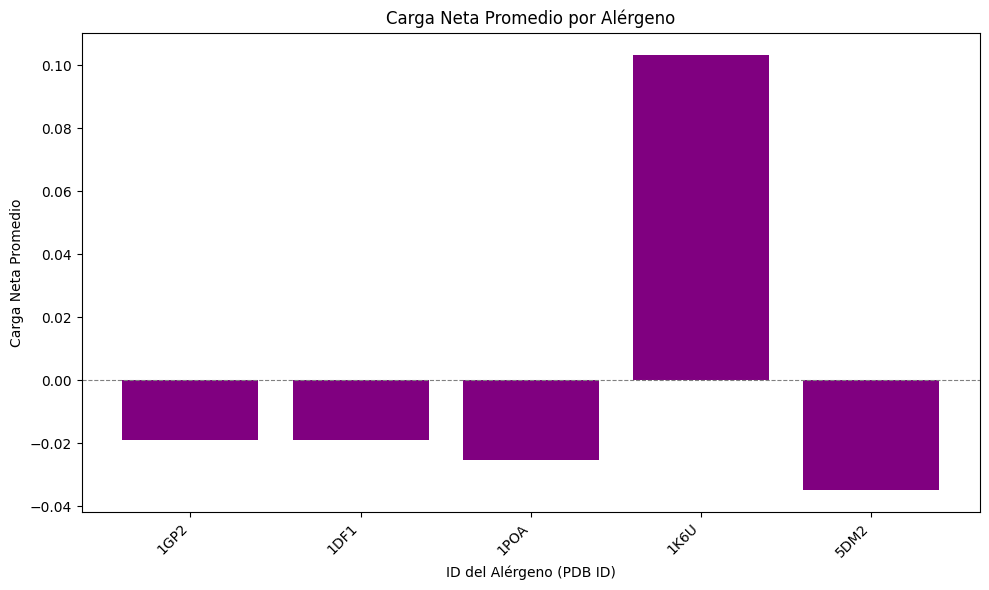


--- Gráfico de Carga Neta Promedio Completado ---


In [ ]:
import matplotlib.pyplot as plt

print("\n--- Generando Gráfico Comparativo de Carga Neta Promedio ---")

pdb_ids_for_charge_plot = list(allergen_net_charges.keys())
net_charges_for_plot = list(allergen_net_charges.values())

if pdb_ids_for_charge_plot:
    plt.figure(figsize=(10, 6))
    plt.bar(pdb_ids_for_charge_plot, net_charges_for_plot, color='purple')
    plt.xlabel('ID del Alérgeno (PDB ID)')
    plt.ylabel('Carga Neta Promedio')
    plt.title('Carga Neta Promedio por Alérgeno')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Línea de referencia en 0
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de carga neta para generar el gráfico.")

print("\n--- Gráfico de Carga Neta Promedio Completado ---")

### 11. Calcular el Punto Isoeléctrico Teórico (pI) por Alérgeno

El punto isoeléctrico (pI) es el pH al cual una molécula (en este caso, una proteína) no tiene carga eléctrica neta. Es una característica importante que influye en la solubilidad, estabilidad y otras propiedades de las proteínas. Lo calcularemos utilizando las secuencias de aminoácidos de cada alérgeno y el módulo `ProtParam` de Biopython.

In [ ]:
from Bio.PDB import PDBParser
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# Diccionario para mapear los nombres de los residuos de 3 letras a 1 letra
# Esto es necesario para ProteinAnalysis
three_to_one_letter_map = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C', 'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H',
    'ILE': 'I', 'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P', 'SER': 'S', 'THR': 'T', 'TRP': 'W',
    'TYR': 'Y', 'VAL': 'V'
}

parser = PDBParser()
pI_results = {}

print("\n--- Cálculo del Punto Isoeléctrico Teórico (pI) por Alérgeno ---")
print("-------------------------------------------------------------------\n")

for pdb_id in allergen_pdb_ids:
    pdb_file_path = f'./{pdb_id}.pdb'
    full_sequence = []

    try:
        structure = parser.get_structure(pdb_id, pdb_file_path)
        for model in structure:
            for chain in model:
                for residue in chain:
                    res_name = residue.get_resname()
                    if res_name in three_to_one_letter_map:
                        full_sequence.append(three_to_one_letter_map[res_name])
                    # else: # Opcional: imprimir residuos no estándar que se ignoran
                        # print(f"  Advertencia: Residuo no estándar '{res_name}' en {pdb_id} será ignorado.")

        if full_sequence:
            protein_sequence = "".join(full_sequence)
            # Crear un objeto ProteinAnalysis
            analysed_seq = ProteinAnalysis(protein_sequence)
            # Calcular el pI
            pI = analysed_seq.isoelectric_point()
            pI_results[pdb_id] = pI
            print(f"Alérgeno {pdb_id}: Punto Isoeléctrico (pI) = {pI:.2f}")
        else:
            print(f"Alérgeno {pdb_id}: No se pudo extraer una secuencia de aminoácidos válida para el cálculo del pI.")

    except Exception as e:
        print(f"Error al procesar el archivo {pdb_file_path}: {e}")

print("\n--- Cálculo del pI Completado ---")


--- Cálculo del Punto Isoeléctrico Teórico (pI) por Alérgeno ---
-------------------------------------------------------------------

Alérgeno 1GP2: Punto Isoeléctrico (pI) = 5.66
Alérgeno 1DF1: Punto Isoeléctrico (pI) = 6.07
Alérgeno 1POA: Punto Isoeléctrico (pI) = 4.90
Alérgeno 1K6U: Punto Isoeléctrico (pI) = 9.27
Alérgeno 5DM2: Punto Isoeléctrico (pI) = 5.12

--- Cálculo del pI Completado ---


### 12. Graficar el Punto Isoeléctrico Teórico por Alérgeno

Este gráfico de barras visualiza el punto isoeléctrico teórico calculado para cada alérgeno, permitiendo una comparación visual rápida de sus propiedades de carga.


--- Generando Gráfico Comparativo del Punto Isoeléctrico (pI) ---


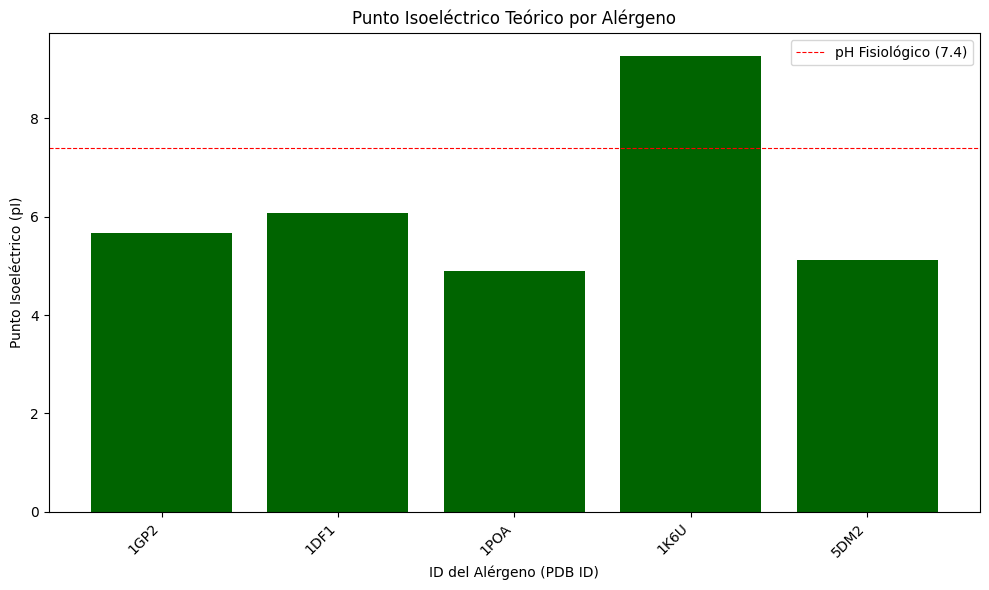


--- Gráfico del pI Completado ---


In [ ]:
import matplotlib.pyplot as plt

print("\n--- Generando Gráfico Comparativo del Punto Isoeléctrico (pI) ---")

pdb_ids_for_pi_plot = list(pI_results.keys())
pi_values_for_plot = list(pI_results.values())

if pdb_ids_for_pi_plot:
    plt.figure(figsize=(10, 6))
    plt.bar(pdb_ids_for_pi_plot, pi_values_for_plot, color='darkgreen')
    plt.xlabel('ID del Alérgeno (PDB ID)')
    plt.ylabel('Punto Isoeléctrico (pI)')
    plt.title('Punto Isoeléctrico Teórico por Alérgeno')
    # Añadir una línea de referencia en pH 7.4 (pH fisiológico)
    plt.axhline(7.4, color='red', linestyle='--', linewidth=0.8, label='pH Fisiológico (7.4)')
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de pI para generar el gráfico.")

print("\n--- Gráfico del pI Completado ---")

### 13. Identificación de Residuos Expuestos en la Superficie (SASA) con DSSP

Para identificar los residuos expuestos en la superficie, calcularemos el Área de Superficie Accesible al Solvente (SASA) para cada residuo en cada alérgeno. Una SASA alta indica que el residuo está más expuesto al solvente y, por lo tanto, es más probable que esté en la superficie y sea parte de una región epitópica.

Utilizaremos el programa DSSP, un estándar de la industria, a través de la interfaz de Biopython.

In [ ]:
# 1. Instalar DSSP (solo la primera vez que se ejecuta en una sesión de Colab)
!sudo apt-get update
!sudo apt-get install dssp

from Bio.PDB import PDBParser, DSSP

parser = PDBParser()
surface_exposed_residues_data = {}

print("\n--- Calculando SASA e identificando residuos expuestos en superficie ---")
print("----------------------------------------------------------------------\n")

# Definir un umbral de SASA para considerar un residuo como 'expuesto'
# Este umbral puede variar, 20-25% de la SASA máxima de un residuo extendido es común.
# Para simplificar, aquí usaremos un valor absoluto para residuos de alanina.
# Un residuo está 'expuesto' si su SASA relativa es >= 25%.
# La SASA máxima para una alanina en un tripéptido GXG es ~129 Å².
# Si usamos 25%, sería ~32.25 Å². Ajustaremos para un umbral razonable.
# Para una aproximación más robusta, se usaría la SASA relativa (SASA del residuo / SASA máxima para ese tipo de residuo en una conformación extendida).
# DSSP ya proporciona SASA absoluta.

sasa_threshold = 20.0 # En Å², ejemplo: un valor bajo para empezar a identificar.

for pdb_id in allergen_pdb_ids:
    pdb_file_path = f'./{pdb_id}.pdb'
    exposed_residues = []

    try:
        structure = parser.get_structure(pdb_id, pdb_file_path)
        model = structure[0] # Asumimos el primer modelo (generalmente el único o el de interés)

        # Para usar DSSP, necesitamos el modelo y el archivo PDB
        dssp_object = DSSP(model, pdb_file_path)

        # La clave en dssp_object es (cadena, residuo_id, tipo_residuo)
        # dssp_object.property_list contiene una lista de tuplas con información.

        for dssp_key in dssp_object.keys():
            # dssp_key es una tupla: (cadena_id, (tipo_residuo, numero_residuo, insercion_code))

            # La información del residuo está en dssp_object[dssp_key]
            # La SASA es el tercer elemento (índice 2) en la tupla de propiedades de DSSP.
            # Los índices son: (idx, AA, secondary_structure, relative_ASA, phi, psi, NH_O_1_idx, NH_O_1_energy, O_NH_1_idx, O_NH_1_energy, NH_O_2_idx, NH_O_2_energy, O_NH_2_idx, O_NH_2_energy)
            # El 4to elemento (índice 3) es la 'SASA relativa' (relative ASA) que es más útil para exposición.
            # DSSP calcula la SASA absoluta y la normaliza a un valor relativo entre 0 y 1.

            # El valor de SASA relativa (dssp_object[dssp_key][3]) es la SASA normalizada entre 0 y 1.
            # Usaremos un umbral de SASA relativa para identificar residuos expuestos.

            # Un umbral del 0.25 (25%) es comúnmente usado para 'expuesto'.
            relative_sasa = dssp_object[dssp_key][3]

            if relative_sasa >= 0.25: # Residuo expuesto si su SASA relativa es del 25% o más
                chain_id = dssp_key[0]
                res_id_tuple = dssp_key[1]
                res_name = dssp_object[dssp_key][1] # Amino acid name
                exposed_residues.append({
                    'chain': chain_id,
                    'res_name': res_name,
                    'res_id': res_id_tuple[1],
                    'relative_sasa': f"{relative_sasa:.2f}"
                })

        surface_exposed_residues_data[pdb_id] = exposed_residues
        print(f"Alérgeno {pdb_id}: {len(exposed_residues)} residuos expuestos en la superficie identificados (umbral SASA relativa >= 0.25).")
        # Mostrar los primeros 5 como ejemplo
        if exposed_residues:
            print("  Primeros 5 residuos expuestos:")
            for i, res in enumerate(exposed_residues[:5]):
                print(f"    Cadena: {res['chain']}, Residuo: {res['res_name']} {res['res_id']}, SASA relativa: {res['relative_sasa']}")
            if len(exposed_residues) > 5:
                print("    ...")
        else:
            print("  No se encontraron residuos expuestos con el umbral especificado.")
        print()

    except Exception as e:
        print(f"Error al procesar el archivo {pdb_file_path} con DSSP: {e}")

print("--- Identificación de residuos expuestos completada ---")

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,962 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,221 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,986 kB]
Get:14 http:/

### 14. Agrupar Residuos Expuestos en Parches de Superficie para la Predicción de Epítopos

Este script agrupa los residuos previamente identificados como expuestos en la superficie en 'parches'. Un parche es un conjunto de residuos expuestos que están espacialmente cercanos entre sí. La identificación de estos parches es un paso clave para predecir regiones epitópicas, ya que los epítopos suelen consistir en un grupo de aminoácidos en la superficie de la proteína.

In [ ]:
from Bio.PDB import PDBParser, NeighborSearch
from collections import deque

# Asegurarse de que 'allergen_pdb_ids' y 'surface_exposed_residues_data' estén definidos.
# 'surface_exposed_residues_data' debe contener los resultados del paso 13 (SASA).

parser = PDBParser()
distance_cutoff = 6.0  # Ångstroms, distancia máxima entre átomos para considerar que dos residuos están en contacto

print("\n--- Agrupando residuos expuestos en parches de superficie ---\n")

# Diccionario para almacenar los parches identificados para cada alérgeno
allergen_surface_patches = {}

for pdb_id in allergen_pdb_ids:
    pdb_file_path = f'./{pdb_id}.pdb'
    print(f"--- Procesando {pdb_id} para parches de superficie ---")

    try:
        structure = parser.get_structure(pdb_id, pdb_file_path)
        model = structure[0] # Asumimos el primer modelo (generalmente el único o el de interés)

        # Crear un conjunto para una búsqueda eficiente de residuos expuestos pre-calculados
        # Contendrá tuplas (chain_id, res_seq_number)
        pre_calculated_exposed_res_keys = set()
        if pdb_id in surface_exposed_residues_data:
            for exp_res_info in surface_exposed_residues_data[pdb_id]:
                pre_calculated_exposed_res_keys.add((exp_res_info['chain'], exp_res_info['res_id']))

        if not pre_calculated_exposed_res_keys:
            print(f"  No se encontraron residuos expuestos pre-calculados para {pdb_id}. Saltando.")
            allergen_surface_patches[pdb_id] = []
            continue

        # Recopilar todos los objetos de Residuo que son expuestos y sus átomos
        all_exposed_residue_objects = []
        all_exposed_atoms = []

        for chain in model:
            for residue in chain:
                res_id_tuple = residue.get_id()
                # Solo consideramos aminoácidos estándar (' ' en el hetero_flag)
                if res_id_tuple[0] == ' ':
                    # Si este residuo es uno de los expuestos pre-calculados
                    if (chain.get_id(), res_id_tuple[1]) in pre_calculated_exposed_res_keys:
                        all_exposed_residue_objects.append(residue)
                        for atom in residue:
                            all_exposed_atoms.append(atom)

        if not all_exposed_atoms:
            print(f"  No se encontraron átomos para residuos expuestos en {pdb_id}. Saltando.")
            allergen_surface_patches[pdb_id] = []
            continue

        # Inicializar NeighborSearch con todos los átomos de los residuos expuestos
        ns = NeighborSearch(all_exposed_atoms)

        current_patches = []
        visited_residues_set = set() # Usaremos los objetos Residue directamente para visited_residues

        for start_res in all_exposed_residue_objects:
            if start_res not in visited_residues_set:
                patch = []
                queue = deque([start_res])
                visited_residues_set.add(start_res)

                while queue:
                    res_to_process = queue.popleft()
                    patch.append(res_to_process)

                    # Buscar vecinos para cada átomo del residuo actual
                    for atom_of_res in res_to_process:
                        neighbor_atoms = ns.search(atom_of_res.get_coord(), distance_cutoff)
                        for n_atom in neighbor_atoms:
                            neighbor_res = n_atom.get_parent()

                            # Asegurarse de que el vecino sea un residuo diferente del actual,
                            # que no haya sido visitado, y que también sea un residuo expuesto
                            if (neighbor_res != res_to_process and
                                neighbor_res not in visited_residues_set):

                                neighbor_res_chain_id = neighbor_res.get_parent().get_id()
                                neighbor_res_seq_number = neighbor_res.get_id()[1]

                                if (neighbor_res_chain_id, neighbor_res_seq_number) in pre_calculated_exposed_res_keys:
                                    visited_residues_set.add(neighbor_res)
                                    queue.append(neighbor_res)

                if patch:
                    current_patches.append(patch)

        allergen_surface_patches[pdb_id] = current_patches
        print(f"  {len(current_patches)} parches de superficie identificados para {pdb_id}:")
        for i, patch in enumerate(current_patches):
            print(f"    Parche {i+1} (Residuos: {len(patch)}):")
            res_list_str = []
            for res in patch:
                res_list_str.append(f"  {res.get_parent().get_id()}-{res.get_resname()}{res.get_id()[1]}")
            # Imprimir en varias líneas si el parche es muy grande
            if len(res_list_str) > 10:
                print(f"      " + ", ".join(res_list_str[:5]) + ", ..., " + ", ".join(res_list_str[-5:]))
            else:
                print(f"      " + ", ".join(res_list_str))
        print()

    except Exception as e:
        print(f"  Error al agrupar residuos en parches para {pdb_id}: {e}\n")

print("--- Agrupación de parches de superficie completada ---\n")


--- Agrupando residuos expuestos en parches de superficie ---

--- Procesando 1GP2 para parches de superficie ---
  2 parches de superficie identificados para 1GP2:
    Parche 1 (Residuos: 317):
        A-LEU5,   A-SER6,   A-ALA7,   A-ASP9,   A-LYS10, ...,   A-ASP97,   A-ASP102,   A-ALA101,   A-ALA98,   A-ALA99
    Parche 2 (Residuos: 1):
        B-HIS62

--- Procesando 1DF1 para parches de superficie ---
  3 parches de superficie identificados para 1DF1:
    Parche 1 (Residuos: 403):
        A-GLN77,   A-TYR78,   A-HIS96,   A-VAL79,   A-THR93, ...,   B-CYS109,   B-SER108,   B-SER106,   B-LYS107,   B-LYS117
    Parche 2 (Residuos: 1):
        A-VAL298
    Parche 3 (Residuos: 3):
        B-SER256,   B-ASN348,   B-VAL346

--- Procesando 1POA para parches de superficie ---
  1 parches de superficie identificados para 1POA:
    Parche 1 (Residuos: 77):
        A-ASN1,   A-THR66,   A-LYS65,   A-LEU2,   A-TYR63, ...,   A-PRO104,   A-ALA101,   A-GLY102,   A-ASP39,   A-VAL37

--- Procesando 1

### 15. Propiedades Físico-Químicas de un Parche de Superficie Específico

Este script calcula la composición de aminoácidos y la carga neta de un parche de superficie seleccionado por el usuario. Estas propiedades son cruciales para entender el comportamiento y la posible interacción de esta región con otras moléculas, incluyendo anticuerpos.

In [ ]:
from collections import Counter

# --- PARÁMETROS CONFIGURABLES ---
pdb_id_to_analyze = '1GP2'
patch_index_to_analyze = 0 # El primer parche es el índice 0
# -----------------------------------

print(f"\n--- Analizando propiedades del Parche {patch_index_to_analyze + 1} para {pdb_id_to_analyze} ---")

if pdb_id_to_analyze in allergen_surface_patches:
    patches_for_allergen = allergen_surface_patches[pdb_id_to_analyze]

    if 0 <= patch_index_to_analyze < len(patches_for_allergen):
        selected_patch = patches_for_allergen[patch_index_to_analyze]

        # 1. Composición de Aminoácidos
        amino_acid_composition = Counter()
        total_residues_in_patch = 0

        for residue in selected_patch:
            res_name = residue.get_resname()
            # Asegurarse de que sea un aminoácido estándar
            if res_name in three_to_one_letter_map: # three_to_one_letter_map contiene todos los estándar
                amino_acid_composition[res_name] += 1
                total_residues_in_patch += 1

        print(f"\n  Composición de Aminoácidos en el Parche {patch_index_to_analyze + 1} ({total_residues_in_patch} residuos):")
        for aa, count in amino_acid_composition.most_common():
            print(f"    {aa}: {count}")

        # 2. Carga Neta del Parche
        total_charge_in_patch = 0
        if 'amino_acid_charges' in globals(): # Reutilizar el diccionario de cargas si ya está definido
            for res_name, count in amino_acid_composition.items():
                if res_name in amino_acid_charges:
                    total_charge_in_patch += amino_acid_charges[res_name] * count

            # Calcular la carga neta promedio por residuo en el parche
            if total_residues_in_patch > 0:
                average_net_charge_in_patch = total_charge_in_patch / total_residues_in_patch
                print(f"\n  Carga neta total del Parche {patch_index_to_analyze + 1}: {total_charge_in_patch:.2f}")
                print(f"  Carga neta promedio por residuo en el Parche {patch_index_to_analyze + 1}: {average_net_charge_in_patch:.3f}")
            else:
                print("\n  No hay residuos válidos para calcular la carga neta en este parche.")
        else:
            print("\n  Advertencia: El diccionario 'amino_acid_charges' no está definido para calcular la carga neta.")

    else:
        print(f"Error: El índice del parche {patch_index_to_analyze} está fuera de rango para el alérgeno {pdb_id_to_analyze}.")
else:
    print(f"Error: No se encontraron parches para el alérgeno {pdb_id_to_analyze}.")

print("\n--- Análisis de propiedades del parche completado ---")


--- Analizando propiedades del Parche 1 para 1GP2 ---

  Composición de Aminoácidos en el Parche 1 (317 residuos):
    GLU: 39
    ASP: 34
    ALA: 32
    ARG: 32
    LYS: 29
    THR: 27
    ASN: 21
    GLN: 18
    SER: 17
    GLY: 15
    PRO: 11
    VAL: 9
    ILE: 8
    PHE: 7
    LEU: 5
    HIS: 5
    MET: 4
    TYR: 2
    TRP: 1
    CYS: 1

  Carga neta total del Parche 1: -12.00
  Carga neta promedio por residuo en el Parche 1: -0.038

--- Análisis de propiedades del parche completado ---


### 16. Propiedades Físico-Químicas de Todos los Parches de Superficie para Cada Alérgeno

Este script calcula la composición de aminoácidos y la carga neta para *todos* los parches de superficie identificados en cada alérgeno. Reutiliza las definiciones de `three_to_one_letter_map` y `amino_acid_charges` de celdas anteriores.

In [ ]:
from collections import Counter

print("\n--- Analizando propiedades de todos los parches de superficie para cada alérgeno ---")
print("--------------------------------------------------------------------------------------\n")

# Asegurarse de que allergen_surface_patches, three_to_one_letter_map y amino_acid_charges estén definidos

if 'allergen_surface_patches' not in globals() or not allergen_surface_patches:
    print("Error: 'allergen_surface_patches' no está definido o está vacío. Asegúrate de ejecutar el paso 14.")
elif 'three_to_one_letter_map' not in globals() or not three_to_one_letter_map:
    print("Error: 'three_to_one_letter_map' no está definido. Asegúrate de ejecutar el paso 11.")
elif 'amino_acid_charges' not in globals() or not amino_acid_charges:
    print("Error: 'amino_acid_charges' no está definido. Asegúrate de ejecutar el paso 9.")
else:
    for pdb_id in allergen_pdb_ids:
        print(f"\n=== Análisis de parches para el alérgeno: {pdb_id} ===")
        if pdb_id in allergen_surface_patches and allergen_surface_patches[pdb_id]:
            patches_for_allergen = allergen_surface_patches[pdb_id]

            for patch_index, selected_patch in enumerate(patches_for_allergen):
                print(f"  --- Parche {patch_index + 1} ---")

                # 1. Composición de Aminoácidos
                amino_acid_composition = Counter()
                total_residues_in_patch = 0

                for residue in selected_patch:
                    res_name = residue.get_resname()
                    # Asegurarse de que sea un aminoácido estándar
                    if res_name in three_to_one_letter_map: # three_to_one_letter_map contiene todos los estándar
                        amino_acid_composition[res_name] += 1
                        total_residues_in_patch += 1

                if total_residues_in_patch > 0:
                    print(f"    Composición de Aminoácidos ({total_residues_in_patch} residuos):")
                    for aa, count in amino_acid_composition.most_common():
                        print(f"      {aa}: {count}")

                    # 2. Carga Neta del Parche
                    total_charge_in_patch = 0
                    for res_name, count in amino_acid_composition.items():
                        if res_name in amino_acid_charges:
                            total_charge_in_patch += amino_acid_charges[res_name] * count

                    average_net_charge_in_patch = total_charge_in_patch / total_residues_in_patch
                    print(f"    Carga neta total del Parche: {total_charge_in_patch:.2f}")
                    print(f"    Carga neta promedio por residuo: {average_net_charge_in_patch:.3f}")
                else:
                    print("    No hay residuos válidos para analizar en este parche.")
        else:
            print(f"  No se encontraron parches de superficie para el alérgeno {pdb_id}.")

print("\n--- Análisis de propiedades de los parches completado ---")


--- Analizando propiedades de todos los parches de superficie para cada alérgeno ---
--------------------------------------------------------------------------------------


=== Análisis de parches para el alérgeno: 1GP2 ===
  --- Parche 1 ---
    Composición de Aminoácidos (317 residuos):
      GLU: 39
      ASP: 34
      ALA: 32
      ARG: 32
      LYS: 29
      THR: 27
      ASN: 21
      GLN: 18
      SER: 17
      GLY: 15
      PRO: 11
      VAL: 9
      ILE: 8
      PHE: 7
      LEU: 5
      HIS: 5
      MET: 4
      TYR: 2
      TRP: 1
      CYS: 1
    Carga neta total del Parche: -12.00
    Carga neta promedio por residuo: -0.038
  --- Parche 2 ---
    Composición de Aminoácidos (1 residuos):
      HIS: 1
    Carga neta total del Parche: 0.00
    Carga neta promedio por residuo: 0.000

=== Análisis de parches para el alérgeno: 1DF1 ===
  --- Parche 1 ---
    Composición de Aminoácidos (403 residuos):
      GLU: 47
      LYS: 34
      THR: 32
      GLN: 29
      GLY: 25
      A

### 17. Calcular la Hidrofobicidad (GRAVY) de un Parche de Superficie Específico

El índice GRAVY (Grand Average of Hydropathy) proporciona una medida de la hidrofobicidad global de una proteína o, en este caso, de un parche específico. Valores más positivos indican mayor hidrofobicidad, mientras que valores negativos sugieren que la región es más hidrofílica. Esto es crucial para entender la interacción del parche con el solvente y otras moléculas.

In [ ]:
from Bio.PDB import PDBParser
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# --- PARÁMETROS CONFIGURABLES ---
pdb_id_for_gravy = '1GP2'
patch_index_for_gravy = 0 # El primer parche es el índice 0
# -----------------------------------

print(f"\n--- Calculando GRAVY para el Parche {patch_index_for_gravy + 1} de {pdb_id_for_gravy} ---")

# Asegurarse de que allergen_surface_patches y three_to_one_letter_map estén definidos
if 'allergen_surface_patches' not in globals() or not allergen_surface_patches:
    print("Error: 'allergen_surface_patches' no está definido o está vacío. Asegúrate de ejecutar el paso 14.")
elif 'three_to_one_letter_map' not in globals() or not three_to_one_letter_map:
    print("Error: 'three_to_one_letter_map' no está definido. Asegúrate de ejecutar el paso 11.")
else:
    if pdb_id_for_gravy in allergen_surface_patches:
        patches_for_allergen = allergen_surface_patches[pdb_id_for_gravy]

        if 0 <= patch_index_for_gravy < len(patches_for_allergen):
            selected_patch = patches_for_allergen[patch_index_for_gravy]
            patch_sequence = []

            for residue in selected_patch:
                res_name = residue.get_resname()
                if res_name in three_to_one_letter_map:
                    patch_sequence.append(three_to_one_letter_map[res_name])

            if patch_sequence:
                protein_sequence_str = "".join(patch_sequence)
                analysed_seq = ProteinAnalysis(protein_sequence_str)
                gravy_score = analysed_seq.gravy()
                print(f"  GRAVY del Parche {patch_index_for_gravy + 1} de {pdb_id_for_gravy}: {gravy_score:.3f}")
            else:
                print(f"  No se pudo extraer una secuencia de aminoácidos válida para el Parche {patch_index_for_gravy + 1}.")
        else:
            print(f"Error: El índice del parche {patch_index_for_gravy} está fuera de rango para el alérgeno {pdb_id_for_gravy}.")
    else:
        print(f"Error: No se encontraron parches para el alérgeno {pdb_id_for_gravy}.")

print("\n--- Cálculo de GRAVY completado ---")


--- Calculando GRAVY para el Parche 1 de 1GP2 ---
  GRAVY del Parche 1 de 1GP2: -1.718

--- Cálculo de GRAVY completado ---


### 18. Calcular la Hidrofobicidad (GRAVY) de TODOS los Parches de Superficie para Cada Alérgeno

Este script calcula el índice GRAVY para *todos* los parches de superficie identificados en cada alérgeno. Esto proporciona una visión comparativa de la hidrofobicidad de las posibles regiones epitópicas en todos los alérgenos.

In [ ]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

print("\n--- Calculando GRAVY para todos los parches de superficie de cada alérgeno ---")
print("------------------------------------------------------------------------------------\n")

# Asegurarse de que allergen_surface_patches y three_to_one_letter_map estén definidos

if 'allergen_surface_patches' not in globals() or not allergen_surface_patches:
    print("Error: 'allergen_surface_patches' no está definido o está vacío. Asegúrate de ejecutar el paso 14.")
elif 'three_to_one_letter_map' not in globals() or not three_to_one_letter_map:
    print("Error: 'three_to_one_letter_map' no está definido. Asegúrate de ejecutar el paso 11.")
else:
    for pdb_id in allergen_pdb_ids:
        print(f"\n=== Análisis de GRAVY para el alérgeno: {pdb_id} ===")
        if pdb_id in allergen_surface_patches and allergen_surface_patches[pdb_id]:
            patches_for_allergen = allergen_surface_patches[pdb_id]

            for patch_index, selected_patch in enumerate(patches_for_allergen):
                patch_sequence = []

                for residue in selected_patch:
                    res_name = residue.get_resname()
                    if res_name in three_to_one_letter_map:
                        patch_sequence.append(three_to_one_letter_map[res_name])

                if patch_sequence:
                    protein_sequence_str = "".join(patch_sequence)
                    analysed_seq = ProteinAnalysis(protein_sequence_str)
                    gravy_score = analysed_seq.gravy()
                    print(f"  Parche {patch_index + 1}: GRAVY = {gravy_score:.3f}")
                else:
                    print(f"  Parche {patch_index + 1}: No se pudo extraer una secuencia de aminoácidos válida para el cálculo del GRAVY.")
        else:
            print(f"  No se encontraron parches de superficie para el alérgeno {pdb_id}.")

print("\n--- Cálculo de GRAVY para todos los parches completado ---")


--- Calculando GRAVY para todos los parches de superficie de cada alérgeno ---
------------------------------------------------------------------------------------


=== Análisis de GRAVY para el alérgeno: 1GP2 ===
  Parche 1: GRAVY = -1.718
  Parche 2: GRAVY = -3.200

=== Análisis de GRAVY para el alérgeno: 1DF1 ===
  Parche 1: GRAVY = -1.363
  Parche 2: GRAVY = 4.200
  Parche 3: GRAVY = -0.033

=== Análisis de GRAVY para el alérgeno: 1POA ===
  Parche 1: GRAVY = -0.957

=== Análisis de GRAVY para el alérgeno: 1K6U ===
  Parche 1: GRAVY = -0.620

=== Análisis de GRAVY para el alérgeno: 5DM2 ===
  Parche 1: GRAVY = -1.488
  Parche 2: GRAVY = -0.400
  Parche 3: GRAVY = 3.800

--- Cálculo de GRAVY para todos los parches completado ---


### 19. Calcular Distancia Euclidiana entre Átomos Específicos Dentro de un Parche de Superficie

Este script permite calcular la distancia euclidiana entre dos átomos definidos por el usuario, pero con la restricción de que ambos átomos deben pertenecer a un parche de superficie previamente identificado para un alérgeno específico. Esto es útil para estudiar la disposición espacial de los residuos dentro de un potencial epítopo.

In [ ]:
from Bio.PDB import PDBParser
import numpy as np

parser = PDBParser()

print("\n--- Calculando distancias entre átomos clave en todos los parches de superficie para todos los alérgenos ---")
print("------------------------------------------------------------------------------------------------------\n")

# Asegurarse de que allergen_surface_patches esté definido del paso 14
if 'allergen_surface_patches' not in globals() or not allergen_surface_patches:
    print("Error: 'allergen_surface_patches' no está definido o está vacío. Asegúrate de ejecutar el paso 14.")
else:
    for pdb_id_for_distance in allergen_pdb_ids:
        print(f"\n=== Análisis de distancias para el alérgeno: {pdb_id_for_distance} ===")
        if pdb_id_for_distance in allergen_surface_patches and allergen_surface_patches[pdb_id_for_distance]:
            patches_for_allergen = allergen_surface_patches[pdb_id_for_distance]

            # Cargar la estructura PDB una vez por alérgeno para eficiencia
            pdb_file_path = f'./{pdb_id_for_distance}.pdb'
            try:
                structure = parser.get_structure(pdb_id_for_distance, pdb_file_path)
            except Exception as e:
                print(f"  Error al cargar la estructura {pdb_id_for_distance}: {e}")
                structure = None
                continue # Pasar al siguiente alérgeno si hay error al cargar la estructura

            if structure:
                for patch_index_for_distance, target_patch in enumerate(patches_for_allergen):
                    print(f"  -- Parche {patch_index_for_distance + 1} --")

                    if len(target_patch) < 2:
                        print(f"    Advertencia: El Parche {patch_index_for_distance + 1} tiene menos de 2 residuos. No se puede calcular la distancia entre dos átomos.\n")
                        continue

                    # Identificar los primeros dos residuos en el parche
                    residue1_in_patch = target_patch[0]
                    residue2_in_patch = target_patch[1]

                    atom1_obj = None
                    atom2_obj = None

                    # Intentar obtener el átomo 'CA' para el primer residuo
                    if 'CA' in residue1_in_patch:
                        atom1_obj = residue1_in_patch['CA']

                    # Intentar obtener el átomo 'CA' para el segundo residuo
                    if 'CA' in residue2_in_patch:
                        atom2_obj = residue2_in_patch['CA']

                    if atom1_obj is not None and atom2_obj is not None:
                        vec1 = atom1_obj.get_vector().get_array()
                        vec2 = atom2_obj.get_vector().get_array()

                        distance = np.linalg.norm(vec1 - vec2)
                        print(f"    Distancia entre CA (Residuo {residue1_in_patch.get_id()[1]}) y CA (Residuo {residue2_in_patch.get_id()[1]}): {distance:.3f} Å")
                    else:
                        print("    Advertencia: No se pudieron encontrar los átomos 'CA' en los primeros dos residuos del parche.")
                        if atom1_obj is None:
                            print(f"      - Átomo CA del residuo {residue1_in_patch.get_id()[1]} no encontrado.")
                        if atom2_obj is None:
                            print(f"      - Átomo CA del residuo {residue2_in_patch.get_id()[1]} no encontrado.")
                    print()

            else:
                print(f"  No se encontraron parches de superficie para el alérgeno {pdb_id_for_distance}.")

print("--- Cálculo de distancias completado para todos los parches y alérgenos ---")


--- Calculando distancias entre átomos clave en todos los parches de superficie para todos los alérgenos ---
------------------------------------------------------------------------------------------------------


=== Análisis de distancias para el alérgeno: 1GP2 ===
  -- Parche 1 --
    Distancia entre CA (Residuo 5) y CA (Residuo 6): 3.861 Å

  -- Parche 2 --
    Advertencia: El Parche 2 tiene menos de 2 residuos. No se puede calcular la distancia entre dos átomos.


=== Análisis de distancias para el alérgeno: 1DF1 ===
  -- Parche 1 --
    Distancia entre CA (Residuo 77) y CA (Residuo 78): 3.849 Å

  -- Parche 2 --
    Advertencia: El Parche 2 tiene menos de 2 residuos. No se puede calcular la distancia entre dos átomos.

  -- Parche 3 --
    Distancia entre CA (Residuo 256) y CA (Residuo 348): 5.272 Å


=== Análisis de distancias para el alérgeno: 1POA ===
  -- Parche 1 --
    Distancia entre CA (Residuo 1) y CA (Residuo 66): 4.917 Å


=== Análisis de distancias para el alérgeno: 

### 20. Visualizar la Distancia Euclidiana entre Átomos Específicos

Este script genera un gráfico 3D para visualizar la posición de los dos átomos seleccionados y la distancia euclidiana calculada entre ellos. Esto proporciona un contexto espacial intuitivo para el valor de la distancia.


--- Visualizando la Distancia Euclidiana ---


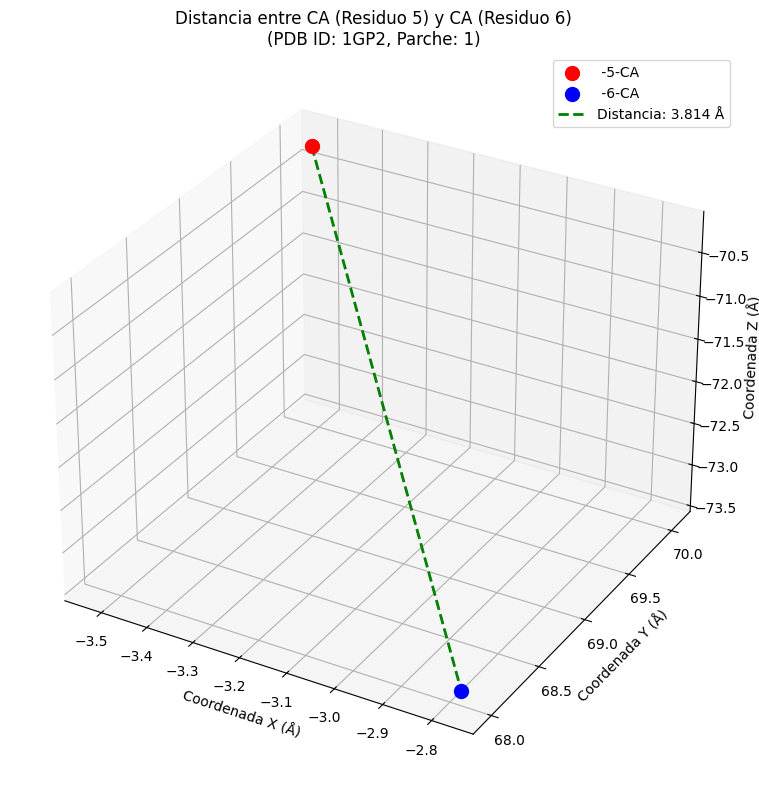


--- Visualización de distancia completada ---


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

print("\n--- Visualizando la Distancia Euclidiana ---")

# Asegurarse de que atom1_obj, atom2_obj y distance estén definidos del paso anterior
if 'atom1_obj' not in globals() or atom1_obj is None:
    print("Error: El átomo 1 no está definido. Asegúrate de ejecutar el paso 19 y de que los átomos se encuentren.")
elif 'atom2_obj' not in globals() or atom2_obj is None:
    print("Error: El átomo 2 no está definido. Asegúrate de ejecutar el paso 19 y de que los átomos se encuentren.")
elif 'distance' not in globals():
    print("Error: La distancia no está calculada. Asegúrate de ejecutar el paso 19.")
else:
    # Obtener las coordenadas de los átomos
    coord1 = atom1_obj.get_coord()
    coord2 = atom2_obj.get_coord()

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plotear los dos átomos como puntos
    ax.scatter(coord1[0], coord1[1], coord1[2], color='red', s=100, label=f'{atom1_obj.get_full_id()[3][0]}-{atom1_obj.get_full_id()[3][1]}-{atom1_obj.get_id()}')
    ax.scatter(coord2[0], coord2[1], coord2[2], color='blue', s=100, label=f'{atom2_obj.get_full_id()[3][0]}-{atom2_obj.get_full_id()[3][1]}-{atom2_obj.get_id()}')

    # Dibujar una línea entre los dos átomos
    ax.plot([coord1[0], coord2[0]], [coord1[1], coord2[1]], [coord1[2], coord2[2]], color='green', linestyle='--', linewidth=2, label=f'Distancia: {distance:.3f} Å')

    # Configurar etiquetas y título
    ax.set_xlabel('Coordenada X (Å)')
    ax.set_ylabel('Coordenada Y (Å)')
    ax.set_zlabel('Coordenada Z (Å)')
    ax.set_title(f'Distancia entre {atom1_obj.get_id()} (Residuo {atom1_obj.get_parent().get_id()[1]}) y {atom2_obj.get_id()} (Residuo {atom2_obj.get_parent().get_id()[1]})\n(PDB ID: {pdb_id_for_distance}, Parche: {patch_index_for_distance + 1})')
    ax.legend()

    plt.tight_layout()
    plt.show()

print("\n--- Visualización de distancia completada ---")

In [ ]:
from Bio.PDB import PDBParser
import numpy as np

parser = PDBParser()
distances_to_plot = []

print("\n--- Recalculando y almacenando distancias para la visualización ---")

if 'allergen_surface_patches' not in globals() or not allergen_surface_patches:
    print("Error: 'allergen_surface_patches' no está definido o está vacío. Asegúrate de ejecutar el paso 14.")
else:
    for pdb_id_for_distance in allergen_pdb_ids:
        pdb_file_path = f'./{pdb_id_for_distance}.pdb'
        try:
            structure = parser.get_structure(pdb_id_for_distance, pdb_file_path)
        except Exception as e:
            print(f"  Error al cargar la estructura {pdb_id_for_distance}: {e}")
            structure = None
            continue

        if structure:
            if pdb_id_for_distance in allergen_surface_patches and allergen_surface_patches[pdb_id_for_distance]:
                patches_for_allergen = allergen_surface_patches[pdb_id_for_distance]

                for patch_index_for_distance, target_patch in enumerate(patches_for_allergen):
                    if len(target_patch) < 2:
                        # print(f"    Advertencia: El Parche {patch_index_for_distance + 1} de {pdb_id_for_distance} tiene menos de 2 residuos. No se puede calcular la distancia.")
                        continue

                    residue1_in_patch = target_patch[0]
                    residue2_in_patch = target_patch[1]

                    atom1_obj = None
                    atom2_obj = None

                    if 'CA' in residue1_in_patch:
                        atom1_obj = residue1_in_patch['CA']
                    if 'CA' in residue2_in_patch:
                        atom2_obj = residue2_in_patch['CA']

                    if atom1_obj is not None and atom2_obj is not None:
                        vec1 = atom1_obj.get_vector().get_array()
                        vec2 = atom2_obj.get_vector().get_array()
                        distance = np.linalg.norm(vec1 - vec2)
                        distances_to_plot.append({
                            'pdb_id': pdb_id_for_distance,
                            'patch_label': f"{pdb_id_for_distance}-P{patch_index_for_distance + 1}",
                            'distance': distance,
                            'res1_id': residue1_in_patch.get_id()[1],
                            'res2_id': residue2_in_patch.get_id()[1]
                        })

print("--- Recalculo y almacenamiento completado ---")



--- Recalculando y almacenando distancias para la visualización ---
--- Recalculo y almacenamiento completado ---



--- Generando Gráfico de Distancias Euclidianas entre Átomos CA en Parches de Superficie ---


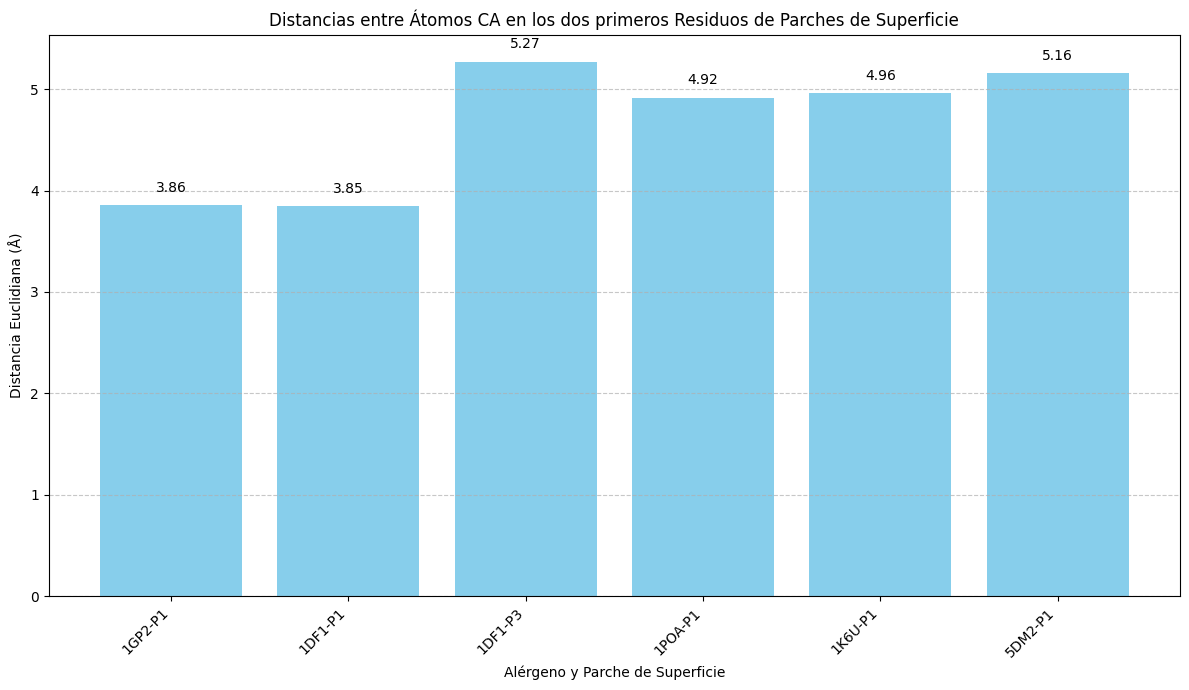

--- Gráfico de Distancias Euclidanas Completado ---


In [ ]:
import matplotlib.pyplot as plt

print("\n--- Generando Gráfico de Distancias Euclidianas entre Átomos CA en Parches de Superficie ---")

if distances_to_plot:
    labels = [d['patch_label'] for d in distances_to_plot]
    distances = [d['distance'] for d in distances_to_plot]

    plt.figure(figsize=(12, 7))
    bars = plt.bar(labels, distances, color='skyblue')
    plt.xlabel('Alérgeno y Parche de Superficie')
    plt.ylabel('Distancia Euclidiana (Å)')
    plt.title('Distancias entre Átomos CA en los dos primeros Residuos de Parches de Superficie')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Añadir el valor de la distancia sobre cada barra
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de distancias para graficar. Asegúrate de que el paso anterior se haya ejecutado correctamente y se hayan encontrado parches válidos.")

print("--- Gráfico de Distancias Euclidanas Completado ---")
